# 09 — Build your own pitch

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jman4162/pitchphys/blob/main/notebooks/09_build_your_own_pitch.ipynb)

A guided tour through `PitchRelease.from_mph_rpm_axis(...)`. We'll build a custom pitch from scratch, simulate it, inspect the trajectory data structure, and compare it to the closest preset.

This notebook is the place to play. Edit the parameters, re-run, and watch the trajectory respond.

In [1]:
# Auto-install pitchphys when running on Colab.
import sys

if "google.colab" in sys.modules:
    !pip install -q "pitchphys[viz] @ git+https://github.com/jman4162/pitchphys.git"

import pitchphys

print(f"pitchphys {pitchphys.__version__}")

pitchphys 0.2.0


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from pitchphys import presets, simulate
from pitchphys.core.pitch import PitchRelease
from pitchphys.viz.plot2d import catcher_view, side_view, top_view
from pitchphys.viz.plot3d import add_spin_axis_arrow, trajectory_3d

## 1. The clock-tilt convention

Spin axis is described as a clock face viewed from behind home plate. 12:00 means pure backspin (Magnus break straight up); 6:00 means pure topspin (Magnus break straight down); 3:00 / 9:00 are sidespin.

Here's a quick clock-face diagram (each tick mark labels the tilt and the resulting Magnus break direction):

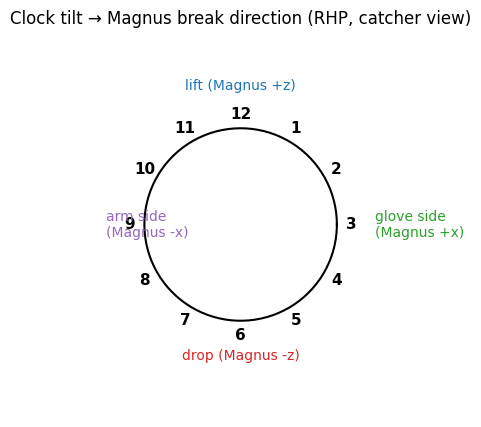

In [3]:
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(aspect="equal"))
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), "k-")
for hour in range(1, 13):
    angle = np.pi / 2 - hour * np.pi / 6  # 12 at top, going clockwise
    x_label, y_label = 1.15 * np.cos(angle), 1.15 * np.sin(angle)
    ax.text(x_label, y_label, f"{hour:d}", ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(0, 1.4, "lift (Magnus +z)", ha="center", color="tab:blue", fontsize=10)
ax.text(0, -1.4, "drop (Magnus -z)", ha="center", color="tab:red", fontsize=10)
ax.text(1.4, 0, "glove side\n(Magnus +x)", va="center", color="tab:green", fontsize=10)
ax.text(-1.4, 0, "arm side\n(Magnus -x)", va="center", color="tab:purple", fontsize=10)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_title("Clock tilt → Magnus break direction (RHP, catcher view)")
ax.axis("off")
plt.show()

## 2. Build a pitch

Edit any of these parameters and re-run the cell. Try a 1:00 cutter, a 4:30 sweeper, or a 7:30 sinker.

In [4]:
my_pitch = PitchRelease.from_mph_rpm_axis(
    speed_mph=88.0,  # release speed
    spin_rpm=2200.0,  # total spin rate
    tilt_clock=2.0,  # 2:00 — slight cut for an RHP
    active_spin_fraction=0.85,
    release_height_ft=6.0,
    release_side_ft=-1.5,  # RHP side
    throwing_hand="R",
)
my_pitch

PitchRelease(speed_m_s=39.33952, launch_angle_deg=-1.0, horizontal_angle_deg=0.0, release_pos_m=array([-0.4572,  0.    ,  1.8288]), spin_rate_rad_s=230.3834612632515, spin_axis=array([ 0.42215263,  0.52317371, -0.74032184]), active_spin_fraction=0.85, metadata={'extension_ft': 6.0, 'throwing_hand': 'R', 'tilt_clock': 2.0})

## 3. Simulate

In [5]:
traj = simulate(my_pitch)
for k, v in traj.break_metrics().items():
    print(f"{k:<28} {v:>+8.3f}")

release_speed_mph             +88.000
plate_speed_mph               +80.508
flight_time_s                  +0.447
plate_x_ft                     -0.230
plate_z_ft                     +2.655
total_drop_in                 +40.135
horizontal_break_in           +15.235
induced_vertical_break_in     +10.587
non_magnus_break_in            +0.000
magnus_break_x_in             +15.235
magnus_break_z_in              +8.826
magnus_break_magnitude_in     +17.607


## 4. Visualize

Three matplotlib views + an interactive 3D scene with the spin-axis arrow at release.

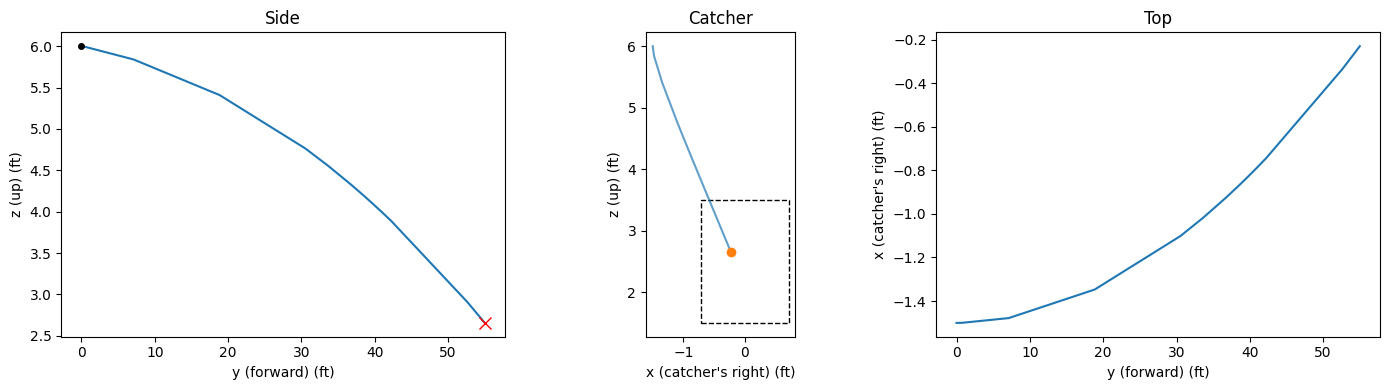

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
side_view(traj, ax=axes[0])
axes[0].set_title("Side")
catcher_view(traj, ax=axes[1])
axes[1].set_title("Catcher")
top_view(traj, ax=axes[2])
axes[2].set_title("Top")
fig.tight_layout()
plt.show()

In [7]:
fig3d = trajectory_3d(traj, label="my pitch")
add_spin_axis_arrow(fig3d, my_pitch, length_ft=2.5)
fig3d.show()

## 5. Inspect the raw data

Everything's a numpy array.

In [8]:
print(f"Time samples: {len(traj.time)}")
print(f"Position shape: {traj.position.shape}")
print(f"Forces tracked: {list(traj.forces)}")
print(f"Magnus force at midflight: {traj.forces['magnus'][len(traj.time) // 2]}")

Time samples: 14
Position shape: (14, 3)
Forces tracked: ['gravity', 'drag', 'magnus']
Magnus force at midflight: [0.52291487 0.00668855 0.3028834 ]


## 6. Compare to the nearest preset

If your pitch is fastball-shaped, here's how it stacks up against the default 4-seam preset.

In [9]:
preset_traj = simulate(presets.four_seam())
print(f"My pitch IVB:        {traj.induced_vertical_break_in:+.2f} in")
print(f"Default 4-seam IVB:  {preset_traj.induced_vertical_break_in:+.2f} in")
print(f"My pitch horiz:      {traj.horizontal_break_in:+.2f} in")
print(f"Default 4-seam horiz: {preset_traj.horizontal_break_in:+.2f} in")

My pitch IVB:        +10.59 in
Default 4-seam IVB:  +20.55 in
My pitch horiz:      +15.23 in
Default 4-seam horiz: -0.08 in


## Takeaway

The full chain: (mph, rpm, tilt, active fraction) → SI conversion → spin-axis vector → ODE integration → break metrics. Each parameter has a well-defined physical meaning, and the model exposes every intermediate quantity (forces, Reynolds number, spin factor, drag/lift coefficients) on `traj` for inspection.